# 01. Основы визуализации данных

Кейс: **«РегионМаркет»**.

## Результат
После ноутбука вы сможете выбрать базовый тип графика, подготовить данные через `groupby`, построить график через объектный API Matplotlib и сделать оси читаемыми.

## 1. Аналитический вопрос важнее библиотеки

Сначала формулируем вопрос, затем выбираем график.

| Вопрос | Тип |
|---|---|
| Что происходит во времени? | line |
| Какая категория лидирует? | bar |
| Как распределены значения? | histogram |
| Есть ли выбросы? | boxplot |
| Есть ли связь двух числовых признаков? | scatter |

In [1]:
from pathlib import Path

def find_project_root() -> Path:
    """Ищет корень учебного комплекта по наличию подготовленного датасета."""
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        target = candidate / "data" / "viz.csv"
        if target.exists():
            return candidate
    raise FileNotFoundError("Не найден data/viz.csv")

PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "viz.csv"
OUTPUT_DIR = PROJECT_ROOT / "teacher" / "out"
OUTPUT_DIR.mkdir(exist_ok=True)
print("Project root:", PROJECT_ROOT)
print("Data:", DATA_PATH)

Project root: <PROJECT_ROOT>\nData: <PROJECT_ROOT>/data/viz.csv\n

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import AutoMinorLocator, FuncFormatter

print("pandas:", pd.__version__)
import matplotlib
print("matplotlib:", matplotlib.__version__)

pandas: 2.2.3
matplotlib: 3.10.8


In [3]:
df = pd.read_csv(DATA_PATH)
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
print("Shape:", df.shape)
display(df.head())

Shape: (1200, 16)


,order_id,order_date,region,channel,customer_type,category,subcategory,quantity,unit_price,discount_percent,revenue,cost,profit,profit_margin,delivery_days,rating
0,RM-00278,2026-01-01,Санкт-Петербург,Партнеры,Повторный,Электроника,Аксессуары,2,25535.30,15,43410.01,32291.26,11118.75,0.2561,3,5.0
1,RM-00380,2026-01-01,Москва,Онлайн,Повторный,Электроника,Аксессуары,3,27689.11,25,62300.50,41398.18,20902.31,0.3355,3,4.9
2,RM-01198,2026-01-01,Ростов-на-Дону,Онлайн,Повторный,Электроника,Аксессуары,1,28165.80,5,26757.51,17040.27,9717.24,0.3632,6,4.4
3,RM-00014,2026-01-02,Самара,Онлайн,Новый,Электроника,Смартфоны,2,26549.60,20,42479.36,26123.07,16356.29,0.3850,7,4.4
4,RM-00053,2026-01-02,Самара,Онлайн,Повторный,Дом и кухня,Посуда,3,8456.20,10,22831.74,15530.02,7301.72,0.3198,3,4.7


## 2. Минимальная проверка данных перед графиком

Нельзя строить выводы, не проверив хотя бы размер, тип даты, пропуски ключевой метрики и дубликаты.

In [4]:
print("Период:", df["order_date"].min().date(), "—", df["order_date"].max().date())
print("Пропуски revenue:", df["revenue"].isna().sum())
print("Полные дубликаты:", df.duplicated().sum())
print("Уникальные заказы:", df["order_id"].nunique())

Период: 2026-01-01 — 2026-06-30
Пропуски revenue: 0
Полные дубликаты: 0
Уникальные заказы: 1200


## 3. Динамика выручки

**Вопрос:** как менялась выручка по месяцам?

Сначала агрегируем данные до уровня месяца.

In [5]:
monthly = (
    df.assign(month=df["order_date"].dt.to_period("M").dt.to_timestamp())
      .groupby("month", as_index=False)
      .agg(revenue=("revenue", "sum"), profit=("profit", "sum"), orders=("order_id", "nunique"))
)
display(monthly)

,month,revenue,profit,orders
0,2026-01-01,5167311.69,1597339.14,203
1,2026-02-01,3503552.74,1044895.29,178
2,2026-03-01,5738548.33,1722257.14,246
3,2026-04-01,4265066.69,1301218.66,179
4,2026-05-01,4842039.47,1451183.96,212
5,2026-06-01,3898139.91,1179384.72,182


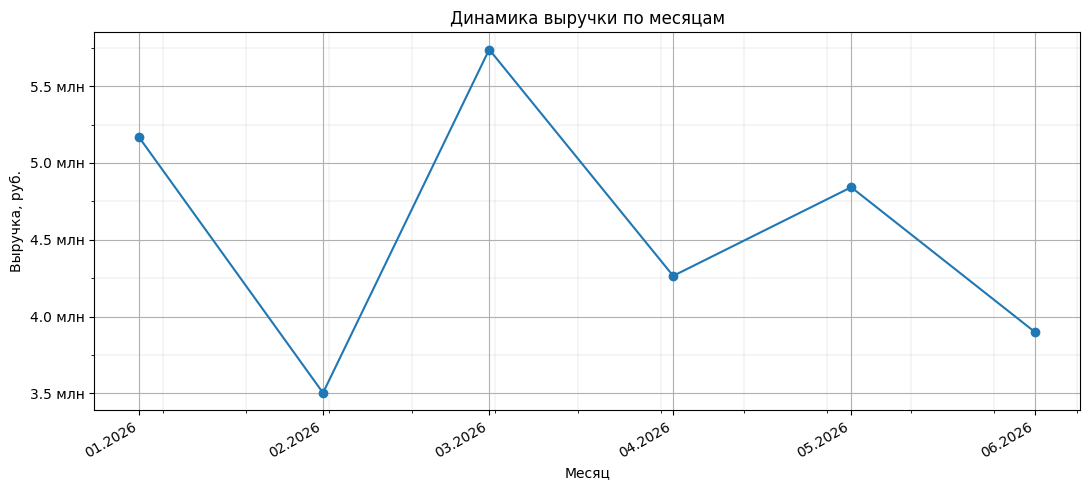

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly["month"], monthly["revenue"], marker="o")
ax.set_title("Динамика выручки по месяцам")
ax.set_xlabel("Месяц")
ax.set_ylabel("Выручка, руб.")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m.%Y"))
ax.xaxis.set_minor_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=2))
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1_000_000:.1f} млн"))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.grid(True, which="major")
ax.grid(True, which="minor", linewidth=0.35, alpha=0.5)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "01_monthly_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

### Контрольная точка 1

Ответьте письменно:

1. В каком месяце выручка максимальна?
2. Видим ли мы причину роста на самом графике?
3. Какое дополнительное разбиение поможет объяснить динамику?

## 4. Сравнение категорий

**Вопрос:** какие категории формируют основную выручку?

In [7]:
category_revenue = (
    df.groupby("category", as_index=False)
      .agg(revenue=("revenue", "sum"))
      .sort_values("revenue", ascending=True)
)
display(category_revenue)

,category,revenue
1,Канцтовары,470770.52
2,Красота,2053518.89
3,Одежда,3862720.20
4,Спорт,3891039.57
0,Дом и кухня,4324626.00
5,Электроника,12811983.65


### Ответы преподавателя к контрольной точке 1

- Максимальная месячная выручка в эталонных данных: **2026-03**.
- Причину роста line chart сам по себе не доказывает. Он показывает изменение метрики; объяснение требует сегментации/дополнительной проверки.
- Полезные разбиения: категория, канал, тип клиента, регион.

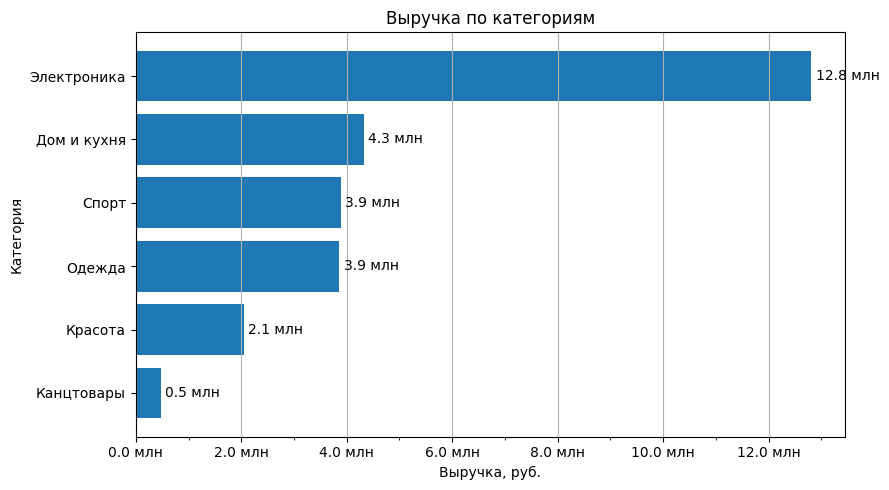

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(category_revenue["category"], category_revenue["revenue"])
ax.set_title("Выручка по категориям")
ax.set_xlabel("Выручка, руб.")
ax.set_ylabel("Категория")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1_000_000:.1f} млн"))
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.grid(True, axis="x", which="major")
ax.bar_label(bars, labels=[f"{v/1_000_000:.1f} млн" for v in category_revenue["revenue"]], padding=3)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "02_category_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

### Контрольная точка 2

Почему для сравнения категорий горизонтальная диаграмма часто удобнее вертикальной, когда подписи длинные?

## Самопроверка

- [ ] я могу объяснить, почему выбран line/bar;
- [ ] дата отсортирована и ось читается;
- [ ] я понимаю, на каком уровне агрегированы данные;
- [ ] у графика есть содержательный вывод, а не только заголовок.

### Ответ преподавателя к контрольной точке 2

Горизонтальные столбцы дают больше места для длинных категориальных подписей и упрощают чтение ранжированного списка. Это не универсальное правило: при коротких подписях и небольшом числе категорий вертикальный bar chart тоже корректен.